##Installation of rdataset

In [2]:
!pip install rdatasets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 10.6 MB/s eta 0:00:00


##Importation of necessary libraries

In [3]:
# import the necessary libraries
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from rdatasets import data
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay,
                             silhouette_score, adjusted_rand_score)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
SEED = 42
sns.set_theme(style='whitegrid')
print('Python:', sys.version.split()[0], '| scikit-learn:', sklearn.__version__)


Python: 3.13.15 | scikit-learn: 1.6.1


##Data Understanding

##1. Dataset-1: Wine(For KNN)

In [4]:
# dataset 1 (for KNN)
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


The preview shows five wines, 13 chemical measurements and one target column. Each row is a wine observation. The target is a cultivar class.

So basically the preview contains 5 rows and 14 columns including the target.

##2. Dataset-2: Chickwts(For Recommendation)

In [5]:
chickwts = data('chickwts').dropna()
chickwts_df = pd.DataFrame(chickwts)
chickwts_df.head()


,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


The above  preview of the chickwts dataset shows individual chicken weights and assigned feed types. `rownames` is an identifier

##3. Data-3 USArrest(For PCA and Clustering)

In [6]:
# Load USArrests and standardize the state-name column.
us_arrest = data('USArrests').copy()

if 'State' in us_arrest.columns:
    pass
elif 'rownames' in us_arrest.columns:
    us_arrest = us_arrest.rename(columns={'rownames': 'State'})
elif not isinstance(us_arrest.index, pd.RangeIndex):
    us_arrest = us_arrest.rename_axis('State').reset_index()
else:
    raise ValueError(
        f"Cannot find state names. Available columns: {us_arrest.columns.tolist()}"
    )

# Keep these copies consistent with the later preparation cells.
arrest_raw = us_arrest.copy()
us_arrest_df = us_arrest.copy()

display(us_arrest.head())
print("Columns:", us_arrest.columns.tolist())

,State,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


Columns: ['State', 'Murder', 'Assault', 'UrbanPop', 'Rape']


The columns are State, Murder, Assault, UrbanPop and Rape; Alabama through California are the first five observations.

In [7]:
# Display the summaries
print('Wine Data:\n', wine_df.head())
print('Chickwts Data:\n', chickwts.head())
print('USArrest Data:\n', us_arrest.head())


Wine Data:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  

Wine contains 178 rows, chickwts 71 and USArrests 50. No exact duplicate rows were reported, no chickwts rows were removed, and the validation assertions passed.

##Verify numeric class labels

In [8]:
# Wine labels are already numeric: no categorical encoder is needed.
assert wine_df['target'].isin([0, 1, 2]).all()
wine_df['target'] = wine_df['target'].astype(int)
display(pd.Series(dict(enumerate(wine.target_names)), name='Class mapping'))
display(wine_df['target'].value_counts().sort_index().rename('Class counts'))

,Class mapping
0,class_0
1,class_1
2,class_2


,Class counts
target,
0,59
1,71
2,48


Class counts are 59, 71 and 48 for classes 0, 1 and 2 respectively.

##Keeping the classificaton compatible target

In [10]:
# Preserve numeric category
wine_df['target'] = wine_df['target'].astype(int)
print('Target dtype:', wine_df['target'].dtype)

Target dtype: int64


The displayed integer dtype confirms that class codes remain numeric.

**Split the data into train and test**

##Held-Out Test set

In [11]:
# Split data into train ans test
# Exclude the target to prevent direct target leakage.
X = wine_df.drop('target', axis=1)
y = wine_df['target']
# Retain the original split for comparison with the submitted results.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training shape:', X_train.shape, '| Test shape:', X_test.shape)

Training shape: (142, 13) | Test shape: (36, 13)


The shapes report how many rows and features are assigned to training and testing. The training set is used to select the model; the test set is used only for final evaluation

##Train only Standardisation

In [12]:
# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
display(pd.DataFrame({'training_mean': X_train_scaled.mean(axis=0), 'training_std': X_train_scaled.std(axis=0)}, index=X_train.columns))

,training_mean,training_std
alcohol,8.303217e-15,1.0
malic_acid,-5.733872e-16,1.0
ash,4.721966e-15,1.0
alcalinity_of_ash,1.223591e-16,1.0
magnesium,-3.698137e-16,1.0
total_phenols,1.833432e-16,1.0
flavanoids,9.907959e-16,1.0
nonflavanoid_phenols,-1.012688e-15,1.0
proanthocyanins,3.635589e-16,1.0
color_intensity,3.197755e-16,1.0


The table above shows training means near zero and population standard deviations near one. Floating point residues such as 1e-16 are effectively zero. Test observations use the training means and standard deviations.

##PCA retaining 95% variance

In [13]:
# Apply PCA to retain 95% variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print('Components:', pca.n_components_, '| Retained variance:', pca.explained_variance_ratio_.sum())

Components: 10 | Retained variance: 0.9619487172898263


10 components retained 96.19% of training variance.

##**Use Tuning**

**Hyperparameter tuning**


Configuring leakage safe model selection

In [ ]:
# Hyperparameter tuning: That is finding the optimal k and distance metrice
knn_pipeline = Pipeline([('scaler', scaler), ('pca', pca), ('knn', KNeighborsClassifier())])
param_grid = {'knn__n_neighbors': [3, 5, 7, 9], 'knn__metric': ['euclidean', 'manhattan']}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(knn_pipeline, param_grid, cv=cv, scoring='accuracy', refit=True)


Now best parameters


## Compare candidate k-NN settings

In [ ]:
# Best parameters
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print('Best parameters:', best_params)
print(f'Best mean CV accuracy: {grid_search.best_score_:.4f}')
display(pd.DataFrame(grid_search.cv_results_)[['param_knn__n_neighbors', 'param_knn__metric', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score'))

Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3}
Best mean CV accuracy: 0.9576


,param_knn__n_neighbors,param_knn__metric,mean_test_score,std_test_score,rank_test_score
0,3,euclidean,0.957635,0.034602,1
4,3,manhattan,0.957635,0.026864,1
5,5,manhattan,0.957635,0.026864,1
1,5,euclidean,0.950246,0.028699,4
7,9,manhattan,0.943596,0.017423,5
3,9,euclidean,0.943596,0.017423,5
2,7,euclidean,0.943350,0.018100,7
6,7,manhattan,0.943350,0.018100,7


The table ranks settings by average validation accuracy across five folds; `std_test_score` measures variation between folds, not a confidence interval. Rank 1 can be shared. `best_params_` selects the first best-scoring configuration when scores tie

The selected settings are k=3 and Euclidean distance, with mean CV accuracy 95.76%. Multiple configurations share the best rank.

##Training K-NN

**Let's retrieve the fitted best model**

In [ ]:
# Train K-NN
best_knn = grid_search.best_estimator_
print('Retained components:', best_knn.named_steps['pca'].n_components_)
print('Retained variance:', best_knn.named_steps['pca'].explained_variance_ratio_.sum())

Retained components: 10
Retained variance: 0.9619487172898263


The final training-fitted PCA retains 10 components and 96.19% of variance.

Now Predict and evaluate

K-NN test accuracy: 0.9444 (94.44%)
              precision    recall  f1-score   support

     class_0       0.93      1.00      0.97        14
     class_1       1.00      0.86      0.92        14
     class_2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36



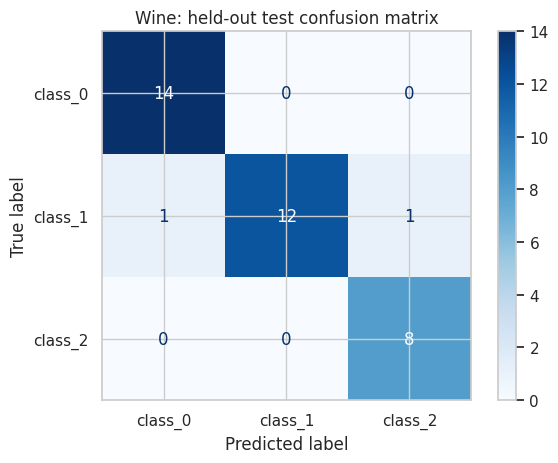

The model correctly classified **34 of 36** test wines. This small holdout provides limited precision; cross-validation supports model selection but is not a second independent test. The report shows which classes are confused. Results describe cultivar classification in this dataset, not general wine quality.

In [ ]:
# Predict and evaluate
y_pred = best_knn.predict(X_test)
wine_accuracy = accuracy_score(y_test, y_pred)
print(f'K-NN test accuracy: {wine_accuracy:.4f} ({wine_accuracy:.2%})')
print(classification_report(y_test, y_pred, target_names=wine.target_names, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=wine.target_names,
                                        cmap='Blues')
plt.title('Wine: held-out test confusion matrix')
plt.tight_layout()
plt.show()
display(Markdown(f'The model correctly classified **{int((y_test.to_numpy()==y_pred).sum())} '
                 f'of {len(y_test)}** test wines. This small holdout provides limited precision; '
                 'cross-validation supports model selection but is not a second independent test. '
                 'The report shows which classes are confused. Results describe cultivar '
                 'classification in this dataset, not general wine quality.'))

## Let's build one profile per feed type

In [ ]:
# Standardize feed level mean weight to compare distinct feed types.
feed_profiles = chickwts.groupby('feed')['weight'].agg(mean_weight='mean', std_weight='std', sample_size='count').sort_index()
display(feed_profiles)
feed_scaler = StandardScaler()
feed_scaled = feed_scaler.fit_transform(feed_profiles[['mean_weight']])


,mean_weight,std_weight,sample_size
feed,,,
casein,323.583333,64.433840,12
horsebean,160.200000,38.625841,10
linseed,218.750000,52.235698,12
meatmeal,276.909091,64.900623,11
soybean,246.428571,54.129068,14
sunflower,328.916667,48.836384,12


There are six feed profiles. Sunflower has the highest observed mean weight (328.92), followed by casein (323.58); horsebean has the lowest (160.20). These summaries describe this sample.

##Now computing one component feed similarity

PCA variance retained: 1.0


feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


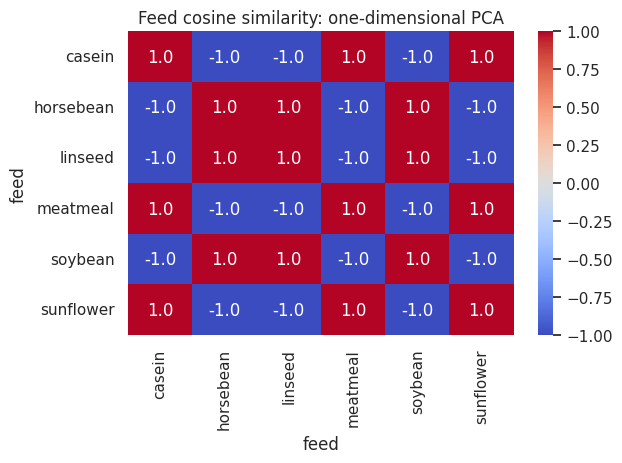

With one weight feature, PCA retains all variance but does not reduce dimensionality. One-dimensional cosine scores are largely +1 or -1, so they create ties. We use mean-weight distance only as a secondary tie-breaker. Feed similarity is descriptive, not evidence of nutritional equivalence or causal effectiveness.

In [ ]:
# Exactly one principal component, followed by cosine similarity.
feed_pca = PCA(n_components=1)
feed_components = feed_pca.fit_transform(feed_scaled)
feed_similarity = pd.DataFrame(cosine_similarity(feed_components), index=feed_profiles.index, columns=feed_profiles.index)
print('PCA variance retained:', feed_pca.explained_variance_ratio_.sum())
display(feed_similarity.round(3))
sns.heatmap(feed_similarity, annot=True, fmt='.1f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feed cosine similarity: one-dimensional PCA')
plt.tight_layout()
plt.show()
display(Markdown('With one weight feature, PCA retains all variance but does not reduce dimensionality. One-dimensional cosine scores are largely +1 or -1, so they create ties. We use mean-weight distance only as a secondary tie-breaker. Feed similarity is descriptive, not evidence of nutritional equivalence or causal effectiveness.'))

PCA retained 100% of the single feature variance. Casein, meatmeal and sunflower form one same sign group; horsebean, linseed and soybean form the other

In [ ]:
# function to recommend similar feed
def recommend_feed(feed_name, num_recommendations=3):
    """Return unique alternative feeds; weight difference breaks cosine ties."""
    feed_name = str(feed_name).strip().lower()
    if feed_name not in feed_profiles.index:
        raise ValueError(f'Unknown feed. Choose from {list(feed_profiles.index)}')
    if not isinstance(num_recommendations, int) or num_recommendations < 1:
        raise ValueError('num_recommendations must be a positive integer')
    # Remove the requested feed so it cannot recommend itself.
    alternatives = feed_profiles.drop(index=feed_name).copy()
    alternatives['cosine_similarity'] = feed_similarity.loc[feed_name, alternatives.index].round(12)
    alternatives['mean_weight_difference'] = abs(alternatives['mean_weight'] - feed_profiles.loc[feed_name, 'mean_weight'])
    # Descending similarity is primary ascending weight difference resolves ties.
    return alternatives.sort_values(['cosine_similarity', 'mean_weight_difference'], ascending=[False, True]).head(num_recommendations)
print('Recommendations for soybean:')
soybean_recommendations = recommend_feed('soybean')
display(soybean_recommendations)
print('Top recommendation for every feed:')
display(pd.DataFrame([{'query_feed': feed, 'recommended_feed': recommend_feed(feed, 1).index[0], 'cosine_similarity': recommend_feed(feed, 1).iloc[0]['cosine_similarity']}
                     for feed in feed_profiles.index]))

Recommendations for soybean:


,mean_weight,std_weight,sample_size,cosine_similarity,mean_weight_difference
feed,,,,,
linseed,218.750000,52.235698,12,1.0,27.678571
horsebean,160.200000,38.625841,10,1.0,86.228571
meatmeal,276.909091,64.900623,11,-1.0,30.480519


Top recommendation for every feed:


,query_feed,recommended_feed,cosine_similarity
0,casein,sunflower,1.0
1,horsebean,linseed,1.0
2,linseed,soybean,1.0
3,meatmeal,casein,1.0
4,soybean,linseed,1.0
5,sunflower,casein,1.0


Soybean returns linseed first (mean-weight difference 27.68), horsebean second (86.23) and meatmeal third (30.48). Meatmeal is closer by weight than horsebean, but its -1 cosine score ranks below horsebean’s +1. This illustrates the limitation of cosine first ranking in one dimension.

## Let's Choose and scale three crime measures

In [ ]:
# Select the three directly relevant crime rate features, then standardize.

selected_features = ['Murder', 'Assault', 'Rape']
crime_scaler = StandardScaler()
crime_scaled = crime_scaler.fit_transform(us_arrest[selected_features])

print('Selected features:', selected_features)
display(pd.DataFrame({'scaled_mean': crime_scaled.mean(axis=0), 'scaled_std': crime_scaled.std(axis=0)}, index=selected_features))

Selected features: ['Murder', 'Assault', 'Rape']


,scaled_mean,scaled_std
Murder,-7.105427e-17,1.0
Assault,1.387779e-16,1.0
Rape,8.593126e-16,1.0


Murder, Assault and Rape are selected because they directly measure arrest rates UrbanPop is a population composition measure, so it is excluded for this objective

All three scaled means are effectively zero and all three population standard deviations are 1.

##Now let's project crime data and choose a K-Means elbow

PCA retained variance: 0.9388771782627572


,k,inertia,elbow_distance
0,1,140.831577,0.000000
1,2,47.124496,0.585035
2,3,32.872499,0.579802
3,4,19.509038,0.567967
4,5,15.882637,0.483797
5,6,13.119857,0.393210
6,7,10.480289,0.301708
7,8,8.374627,0.206240
8,9,7.151567,0.104215
9,10,6.223290,0.000000


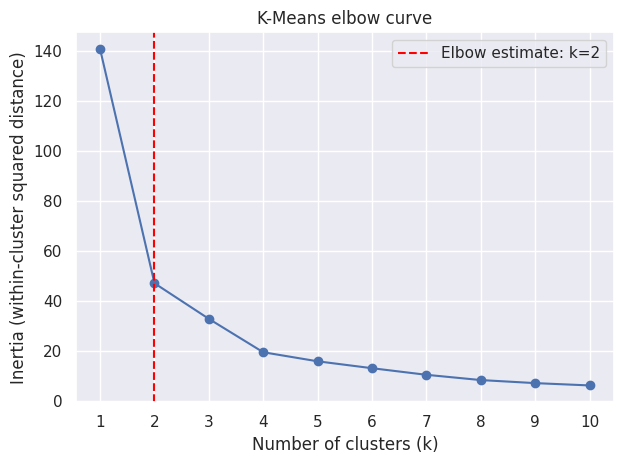

Selected K-Means k: 2


In [ ]:
# Apply PCA only to the three selected features.
crime_pca = PCA(n_components=2)
crime_components = crime_pca.fit_transform(crime_scaled)

print('PCA retained variance:', crime_pca.explained_variance_ratio_.sum())
# Elbow heuristic: maximum distance below the normalized endpoint line.

k_values = np.arange(1, 11)
kmeans_candidates = [KMeans(n_clusters=int(k), n_init=20, random_state=SEED).fit(crime_components)
                     for k in k_values]
inertias = np.array([model.inertia_ for model in kmeans_candidates])
x_normalized = (k_values-k_values.min())/(k_values.max()-k_values.min())
y_normalized = (inertias-inertias.min())/(inertias.max()-inertias.min())
elbow_distances = (1-x_normalized)-y_normalized
best_k = int(k_values[1:-1][np.argmax(elbow_distances[1:-1])])
display(pd.DataFrame({'k': k_values, 'inertia': inertias, 'elbow_distance': elbow_distances}))

sns.set_style('darkgrid')
plt.plot(k_values, inertias, 'o-')
plt.axvline(best_k, color='red', linestyle='--', label=f'Elbow estimate: k={best_k}')
plt.xticks(k_values)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster squared distance)')
plt.title('K-Means elbow curve')
plt.legend()
plt.tight_layout()
plt.show()
print('Selected K-Means k:', best_k)

Two components summarize the three standardized crime features. The variance output quantifies information retained. Inertia sums squared distances to cluster centres and always tends to decrease as k increases. The normalized distance heuristic chooses an interior point furthest below the line joining the curve endpoints. The red line identifies that estimated elbow; inspect nearby k values because the heuristic does not establish a uniquely correct number of real-world groups

The two PCs retain 93.89% of variance. The elbow heuristic selects k=2; inertia drops from 140.83 at k=1 to 47.12 at k=2.

##Let's continue with Gaussian mixture using BIC

,components,BIC,converged
0,1,307.212112,True
1,2,293.280223,True
2,3,303.989880,True
3,4,316.699126,True
4,5,317.340245,True
5,6,319.161374,True
6,7,332.713781,True
7,8,326.483238,True
8,9,335.575811,True
9,10,326.728412,True


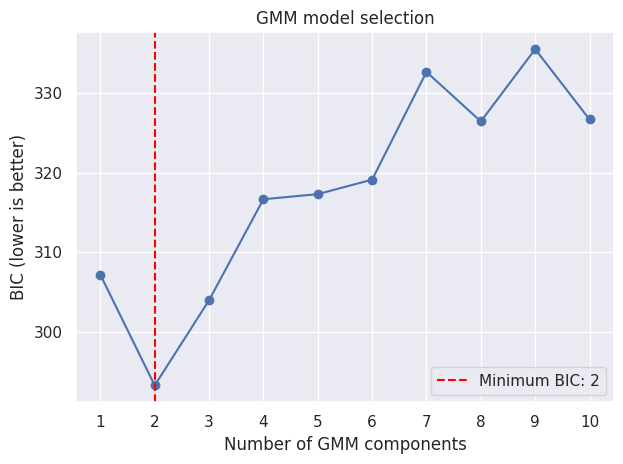

In [ ]:
# Apply selected K-Means model for hard assignments.
kmeans = kmeans_candidates[best_k-1]
kmeans_labels = kmeans.labels_

# Choose GMM components by minimum BIC, including a possible one component solution.
gmm_candidates = [GaussianMixture(n_components=int(k), covariance_type='full',
                                  n_init=10, reg_covar=1e-6, random_state=SEED).fit(crime_components)
                  for k in k_values]
bic_values = np.array([model.bic(crime_components) for model in gmm_candidates])
best_gmm_index = int(np.argmin(bic_values))
best_gmm_k = int(k_values[best_gmm_index])

display(pd.DataFrame({'components': k_values, 'BIC': bic_values, 'converged': [m.converged_ for m in gmm_candidates]}))
sns.set_style('darkgrid')
plt.plot(k_values, bic_values, 'o-')
plt.axvline(best_gmm_k, color='red', linestyle='--', label=f'Minimum BIC: {best_gmm_k}')
plt.xticks(k_values)
plt.xlabel('Number of GMM components')
plt.ylabel('BIC (lower is better)')
plt.title('GMM model selection')
plt.legend()
plt.tight_layout()
plt.show()

K-Means labels are taken from the selected fitted candidate. The GMM table compares one to ten full covariance Gaussian mixtures. BIC balances fit and complexity; smaller values are preferred. The red line identifies the minimum among candidates, while the convergence column confirms numerical termination. Convergence is not evidence that the grouping is substantively correct.

The minimum BIC selects two components. All candidate GMMs report convergence.

## Inspect uncertain GMM memberships

In [ ]:
# Apply the selected GMM and show probabilistic memberships.
gmm = gmm_candidates[best_gmm_index]
gmm_labels = gmm.predict(crime_components)
gmm_probabilities = gmm.predict_proba(crime_components)
probability_table = pd.DataFrame(gmm_probabilities, index=us_arrest['State'], columns=[f'Component_{j}' for j in range(best_gmm_k)])
probability_table['assigned_component'] = gmm_labels
probability_table['max_membership_probability'] = gmm_probabilities.max(axis=1)
display(probability_table.sort_values('max_membership_probability').head(10))

,Component_0,Component_1,assigned_component,max_membership_probability
State,,,,
Missouri,0.883932,0.116068,0,0.883932
Illinois,0.105502,0.894498,1,0.894498
Texas,0.077039,0.922961,1,0.922961
Tennessee,0.076287,0.923713,1,0.923713
New York,0.036445,0.963555,1,0.963555
Arizona,0.028314,0.971686,1,0.971686
Arkansas,0.987282,0.012718,0,0.987282
New Mexico,0.005299,0.994701,1,0.994701
Maryland,0.005070,0.994930,1,0.994930


Each component column gives a state’s model based membership probability; component probabilities across a row sum to one. `assigned_component` chooses the largest probability. Sorting by maximum probability puts less decisive assignments first. These probabilities depend on the fitted Gaussian model, they are not crime probabilities or independently validated confidence levels.

The table is sorted from less to more decisive assignments. Even the lowest maximum membership is about 0.884, so “less decisive” is relative within this fitted model.

##**Compare cluster assignments and profiles**

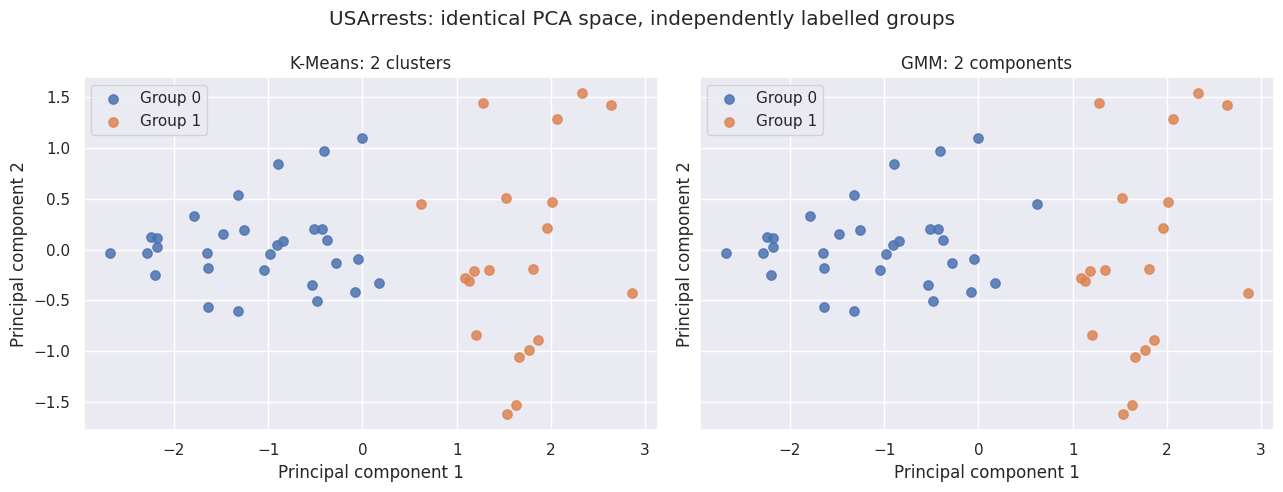

,model,groups,silhouette
0,K-Means,2,0.568035
1,GMM,2,0.560973


Silhouette: higher indicates greater separation; NaN means undefined for one group.
Adjusted Rand agreement between partitions: 0.920

KMeans: group sizes and mean crime rates in original units


,states,Murder,Assault,Rape
KMeans,,,,
0,30,4.870,114.433333,15.943333
1,20,12.165,255.250000,29.165000



GMM: group sizes and mean crime rates in original units


,states,Murder,Assault,Rape
GMM,,,,
0,31,5.003226,116.483871,16.338710
1,19,12.331579,259.315789,29.215789


GMM,0,1
KMeans,,
0,30,0
1,1,19


In [ ]:
# Visualize the Cluster
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, labels, title in [(axes[0], kmeans_labels, f'K-Means: {best_k} clusters'),
                           (axes[1], gmm_labels, f'GMM: {best_gmm_k} components')]:
    for label in np.unique(labels):
        mask = labels == label
        ax.scatter(crime_components[mask, 0], crime_components[mask, 1],
                   label=f'Group {label}', s=45, alpha=0.85)
    ax.set(title=title, xlabel='Principal component 1', ylabel='Principal component 2')
    ax.legend()

sns.set_style('darkgrid')
plt.suptitle('USArrests: identical PCA space, independently labelled groups')
plt.tight_layout()
plt.show()
# silhouette is undefined for a single group
def safe_silhouette(labels):
    return silhouette_score(crime_components, labels) if 1 < len(np.unique(labels)) < len(labels) else np.nan
comparison = pd.DataFrame({'model': ['K-Means', 'GMM'], 'groups': [best_k, best_gmm_k], 'silhouette': [safe_silhouette(kmeans_labels), safe_silhouette(gmm_labels)]})
display(comparison)
print('Silhouette: higher indicates greater separation; NaN means undefined for one group.')
print(f'Adjusted Rand agreement between partitions: {adjusted_rand_score(kmeans_labels, gmm_labels):.3f}')
clustered_states = us_arrest.assign(KMeans=kmeans_labels, GMM=gmm_labels)
for model in ['KMeans', 'GMM']:
    print(f'\n{model}: group sizes and mean crime rates in original units')
    display(clustered_states.groupby(model).agg(states=('State', 'count'), Murder=('Murder', 'mean'), Assault=('Assault', 'mean'), Rape=('Rape', 'mean')))
display(pd.crosstab(clustered_states['KMeans'], clustered_states['GMM']))

K-Means silhouette is approximately 0.568 versus 0.561 for GMM; the small difference alone does not establish a definitive winner. Adjusted Rand agreement is 0.920. K-Means divides the states 30/20, whereas GMM divides them 31/19; the cross tab shows only one differing assignment.

##**Conclusions**

##Let's summarize findngs and check rubric conditions

In [ ]:
km_profiles = clustered_states.groupby('KMeans')[selected_features].mean()
highest_assault_group = int(km_profiles['Assault'].idxmax())
lowest_assault_group = int(km_profiles['Assault'].idxmin())
gmm_interpretation = (
    'BIC selected one GMM component, so this search does not support multiple Gaussian groups; '
    'all membership probabilities are 1 and a silhouette score is undefined.'
    if best_gmm_k == 1 else
    f'BIC selected {best_gmm_k} GMM components. The probability table highlights states with '
    'less decisive membership; hard labels discard this uncertainty.')
display(Markdown(
    f'- **Wine:** held-out accuracy is {wine_accuracy:.2%}; the selected settings are '
    f"{grid_search.best_params_}. PCA retains {best_knn.named_steps['pca'].explained_variance_ratio_.sum():.2%} "
    'of training variance. Scaling and PCA are fitted separately inside each CV fold.\n'
    f'- **Feeds:** the top soybean alternative is **{soybean_recommendations.index[0]}** under '
    'the stated cosine-first, weight-distance tie-break rule. Repeated cosine scores reflect '
    'one-dimensional geometry, not strong evidence of equal feed performance.\n'
    f'- **Crime:** two PCs retain {crime_pca.explained_variance_ratio_.sum():.2%} of selected-feature variance. '
    f'The elbow heuristic selects {best_k} K-Means groups. Group {highest_assault_group} has the highest '
    f'mean Assault rate ({km_profiles.loc[highest_assault_group, "Assault"]:.1f}), while group '
    f'{lowest_assault_group} has the lowest ({km_profiles.loc[lowest_assault_group, "Assault"]:.1f}). '
    'These summaries can guide descriptive comparisons, not causal policy or individual judgements.\n'
    f'- **Model comparison:** {gmm_interpretation} K-Means uses compact distance-based groups; '
    'GMM uses Gaussian densities and soft assignments. Their labels and counts need not agree.\n'
    '- **Next steps:** validate stability across samples and seeds, and obtain richer feed attributes '
    'and current crime data before operational use.'))

# Check invariants that directly address rubric requirements and earlier defects.
assert best_knn.named_steps['pca'].explained_variance_ratio_.sum() >= 0.95
assert feed_components.shape == (len(feed_profiles), 1)
assert crime_components.shape == (len(us_arrest), 2)
assert crime_pca.n_features_in_ == 3
assert np.allclose(gmm_probabilities.sum(axis=1), 1)
assert all(model.converged_ for model in gmm_candidates)
for feed in feed_profiles.index:
    recommendations = recommend_feed(feed, 5)
    assert recommendations.index.is_unique and feed not in recommendations.index
assert best_gmm_k == int(k_values[np.argmin(bic_values)])
print('All rubric-related implementation checks passed.')

- **Wine:** held-out accuracy is 94.44%; the selected settings are {'knn__metric': 'euclidean', 'knn__n_neighbors': 3}. PCA retains 96.19% of training variance. Scaling and PCA are fitted separately inside each CV fold.
- **Feeds:** the top soybean alternative is **linseed** under the stated cosine-first, weight-distance tie-break rule. Repeated cosine scores reflect one-dimensional geometry, not strong evidence of equal feed performance.
- **Crime:** two PCs retain 93.89% of selected-feature variance. The elbow heuristic selects 2 K-Means groups. Group 1 has the highest mean Assault rate (255.2), while group 0 has the lowest (114.4). These summaries can guide descriptive comparisons, not causal policy or individual judgements.
- **Model comparison:** BIC selected 2 GMM components. The probability table highlights states with less decisive membership; hard labels discard this uncertainty. K-Means uses compact distance-based groups; GMM uses Gaussian densities and soft assignments. Their labels and counts need not agree.
- **Next steps:** validate stability across samples and seeds, and obtain richer feed attributes and current crime data before operational use.

All rubric-related implementation checks passed.
